In [ ]:
# Import packages
import numpy as np
import torch
from torch import nn
import math
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Seed for reproducibility.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
'''
  To generate the actual sine wave data
'''
def generate_sine_wave(train_data_length=1024):
    train_data = torch.zeros((train_data_length, 2))
    train_data[:, 0] = 2.0 * math.pi * torch.rand(train_data_length)
    train_data[:, 1] = torch.sin(train_data[:, 0])

    x = train_data[:, 0]
    y = train_data[:, 1]

    data = torch.stack([x, y], dim=1)

    return data

In [ ]:
'''
  This function converts the data into batches
  for GAN training
'''
def dataloader(train_data, batch_size=32):
    labels = torch.zeros(train_data.size(0))
    dataset = TensorDataset(train_data, labels)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
'''
    This function performs the GAN training based
    on provided parameters
'''
def train_gan(discriminator, generator, train_loader, discriminator_lr=0.0002, generator_lr=0.0002, num_epochs = 500):
  loss_function = nn.BCELoss()

  # Define optimizers for both networks
  d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=discriminator_lr, betas=(0.5, 0.999))
  g_optimizer = torch.optim.Adam(generator.parameters(), lr=generator_lr, betas=(0.5, 0.999))

  # Get all losses values for plotting and output
  avg_g_loss, avg_d_loss = [], []

  for epoch in range(num_epochs):
    epoch_d_loss, epoch_g_loss = [], []
    num_batches = len(train_loader)

    for n, (real_samples, _) in enumerate(train_loader):
      batch_size = real_samples.size(0)

      # Labels for discriminator training
      real_samples_labels = torch.ones((batch_size, 1))
      generated_samples_labels = torch.zeros((batch_size, 1))


      # Training the discriminator
      latent_space_samples = torch.randn((batch_size, 16))
      generated_samples = generator(latent_space_samples).detach()
      all_samples = torch.cat((real_samples, generated_samples))
      all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

      discriminator.zero_grad()
      output_discriminator = discriminator(all_samples)
      loss_discriminator = loss_function(output_discriminator, all_samples_labels)
      loss_discriminator.backward()
      d_optimizer.step()
      epoch_d_loss.append(loss_discriminator.item())

      # Training the generator
      latent_space_samples = torch.randn((batch_size, 16))
      generator.zero_grad()
      generated_samples = generator(latent_space_samples)
      output_discriminator_generated = discriminator(generated_samples)
      loss_generator = loss_function( output_discriminator_generated,real_samples_labels)
      loss_generator.backward()
      g_optimizer.step()
      epoch_g_loss.append(loss_generator.item())

    # Print average loss for the epoch
    if epoch % 100 == 0:
      avg_d_loss.append(np.mean(epoch_d_loss))
      avg_g_loss.append(np.mean(epoch_g_loss))
      print(f"Epoch {epoch}: Discriminator Loss.: {avg_d_loss[-1]:.4f} <<--->> Generator Loss.: {avg_g_loss[-1]:.4f}")

  return avg_d_loss, avg_g_loss

In [ ]:
"""
  This function evaluate performance of the GANs using mean,
  and std of real and generated samples on both axes.
"""
def evaluate_gan(real_samples, generated_samples, label="GAN"):
    print(f"\n{'='*55}")
    print(f"  Evaluation: {label}")
    print(f"{'='*55}")
    print(f"{'Metric':<22} {'Real':>8} {'Generated':>12} {'Difference':>8}")
    print(f"{'-'*55}")

    for axis, idx in [('X', 0), ('Y', 1)]:
        r_mean = real_samples[:, idx].mean()
        g_mean = generated_samples[:, idx].mean()
        r_std = real_samples[:, idx].std()
        g_std = generated_samples[:, idx].std()

        print(f"  Mean (axis {axis}) {r_mean:>8.4f} {g_mean:>12.4f} {abs(r_mean - g_mean):>8.4f}")
        print(f"  Std  (axis {axis}) {r_std:>8.4f} {g_std:>12.4f} {abs(r_std  - g_std ):>8.4f}")

    print(f"{'='*55}\n")

In [ ]:
"""
  Generates specified random samples from trained generator Generated 2points,
  if samples are not specified, it defaults to 1000
"""
def generate_gan_samples(generator, num_samples=1000):
    latent_space = torch.randn(num_samples, 16)
    return generator(latent_space).detach().numpy()

In [ ]:
'''
  Plots the losses from training the
  Discriminator and Generator
'''
def plot_losses(g_loss,d_loss, title="Training Losses"):
  plt.figure(figsize=(9, 4))
  plt.plot(g_loss, label="Generator", color="#E76F51", linewidth=2)
  plt.plot(d_loss, label="Discriminator", color="#2A9D8F", linewidth=2)
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title(title)
  plt.legend()
  plt.tight_layout()
  plt.show()

In [ ]:
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(2, 256),
        nn.ReLU(), # activation function
        nn.Dropout(0.3), # dropout to prevent overfitting
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64, 1),
        nn.Sigmoid(), # sigmoid activation to produce a probability
      )

  # Describe how the forward pass is calculated.
  def forward(self, x):
    output = self.model(x)
    return output

In [ ]:
class Generator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(16, 16),
        nn.ReLU(),
        nn.Linear(16, 32),
        nn.ReLU(),
        nn.Linear(32, 2)
    )

  def forward(self, x):
    output = self.model(x)
    return output

In [ ]:
# Assign the discriminator and generator object for use
# Dsicriminator object
discriminator = Discriminator()

# Generator object
generator = Generator()

In [ ]:
# Generate sine wave data and set train loader on the generated data
train_data = generate_sine_wave(1024)
train_loader = dataloader(train_data)

In [ ]:
# Train GAN on data
discrimininator_loss, generator_loss = train_gan(discriminator, generator, train_loader, num_epochs=1000)

Epoch 0: Discriminator Loss.: 0.5529 <<--->> Generator Loss.: 0.8163
Epoch 100: Discriminator Loss.: 0.5322 <<--->> Generator Loss.: 0.9661
Epoch 200: Discriminator Loss.: 0.6002 <<--->> Generator Loss.: 0.8974
Epoch 300: Discriminator Loss.: 0.6808 <<--->> Generator Loss.: 0.7438
Epoch 400: Discriminator Loss.: 0.6782 <<--->> Generator Loss.: 0.7313
Epoch 500: Discriminator Loss.: 0.6808 <<--->> Generator Loss.: 0.7164
Epoch 600: Discriminator Loss.: 0.6876 <<--->> Generator Loss.: 0.7238
Epoch 700: Discriminator Loss.: 0.6923 <<--->> Generator Loss.: 0.7032
Epoch 800: Discriminator Loss.: 0.6910 <<--->> Generator Loss.: 0.6965
Epoch 900: Discriminator Loss.: 0.6906 <<--->> Generator Loss.: 0.6976


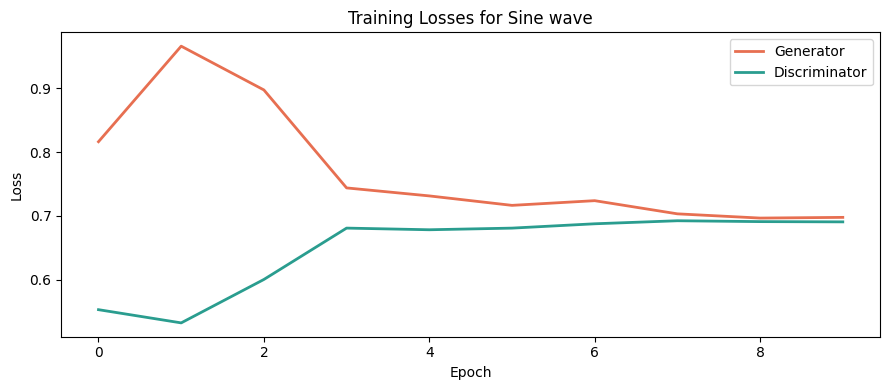

In [ ]:
# Plot losses on GAN data (sine)
plot_losses(generator_loss,discrimininator_loss, "Training Losses for Sine wave")

In [ ]:
# Generate 1000 random 2D points for the generator
generated_samples_numpy = generate_gan_samples(generator)

# Convert train_data to numpy for plotting
train_data_numpy = train_data.numpy()

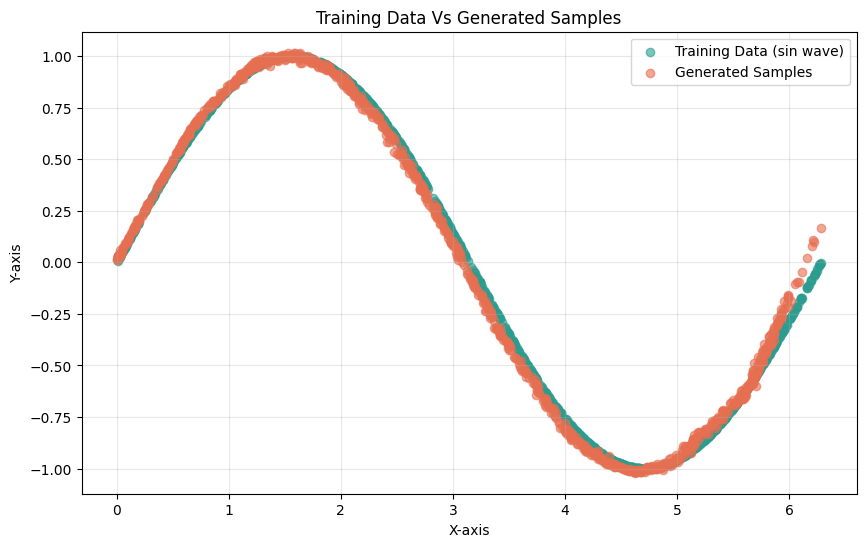

In [ ]:
# Plot the training data and generated samples
plt.figure(figsize=(10, 6))

# real data
plt.scatter(train_data_numpy[:, 0], train_data_numpy[:, 1], label='Training Data (sin wave)', alpha=0.6, color="#2A9D8F")

# sample data
plt.scatter(generated_samples_numpy[:, 0], generated_samples_numpy[:, 1], label='Generated Samples', alpha=0.6, color="#E76F51")

plt.title('Training Data Vs Generated Samples')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Evaluation metrics for sine wave GAN
evaluate_gan(train_data_numpy, generated_samples_numpy, label="Sine Wave GAN")


  Evaluation: Sine Wave GAN
Metric                     Real    Generated Difference
-------------------------------------------------------
  Mean (axis X)   3.1095       3.0936   0.0159
  Std  (axis X)   1.8231       1.8209   0.0022
  Mean (axis Y)  -0.0038      -0.0140   0.0103
  Std  (axis Y)   0.7117       0.7133   0.0016



# **Part 1: A noisy parametric curve: y = sin(2x) + 0.3cos(5x) + epsilon (Noise)**

In [ ]:
'''
  Generate noisy parametric curve
'''
def generate_noisy_curve(n_samples=1024, noise_std=0.1):
  x = 2.0 * math.pi * torch.rand(n_samples)
  y = torch.sin(2 * x) + 0.3 * torch.cos(5 * x) + noise_std * torch.randn(n_samples)

  data = torch.stack([x, y], dim=1)

  return data

In [ ]:
# Generates parametric data with noise
# also loads into the dataloader

train_data = generate_noisy_curve(1024)
train_loader = dataloader(train_data)

In [ ]:
# Original GAN architecture
# on parametric data
generator_v1 = Generator()
discriminator_v1 = Discriminator()

print("Training Original GAN architecture")
discrimininator_v1_loss, generator_v1_loss = train_gan(discriminator_v1, generator_v1, train_loader, num_epochs=1000)

Training Original GAN architecture
Epoch 0: Discriminator Loss.: 0.5732 <<--->> Generator Loss.: 0.7476
Epoch 100: Discriminator Loss.: 0.6374 <<--->> Generator Loss.: 0.9225
Epoch 200: Discriminator Loss.: 0.6139 <<--->> Generator Loss.: 0.9313
Epoch 300: Discriminator Loss.: 0.5660 <<--->> Generator Loss.: 1.0268
Epoch 400: Discriminator Loss.: 0.5865 <<--->> Generator Loss.: 1.0022
Epoch 500: Discriminator Loss.: 0.5912 <<--->> Generator Loss.: 0.9645
Epoch 600: Discriminator Loss.: 0.6134 <<--->> Generator Loss.: 0.8660
Epoch 700: Discriminator Loss.: 0.6404 <<--->> Generator Loss.: 0.8511
Epoch 800: Discriminator Loss.: 0.6322 <<--->> Generator Loss.: 0.8463
Epoch 900: Discriminator Loss.: 0.6540 <<--->> Generator Loss.: 0.7967


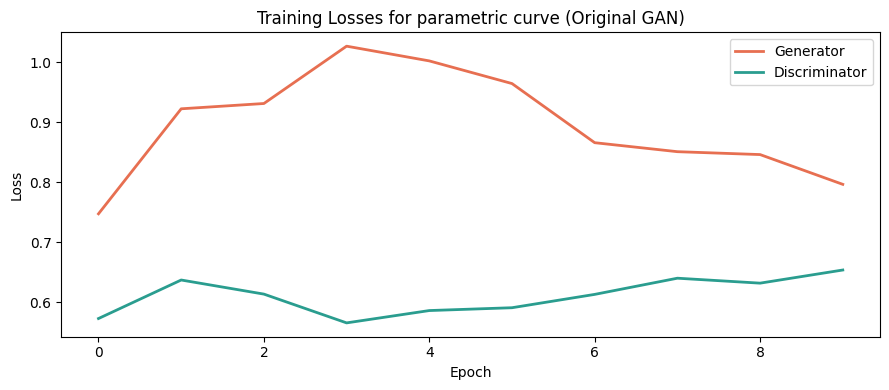

In [ ]:
# Plot losses on GAN data (parametric curve)
plot_losses(generator_v1_loss, discrimininator_v1_loss, "Training Losses for parametric curve (Original GAN)")

In [ ]:
# Generate 1000 samples
generated_samples_v1 = generate_gan_samples(generator_v1)
actual_data = train_data.numpy()

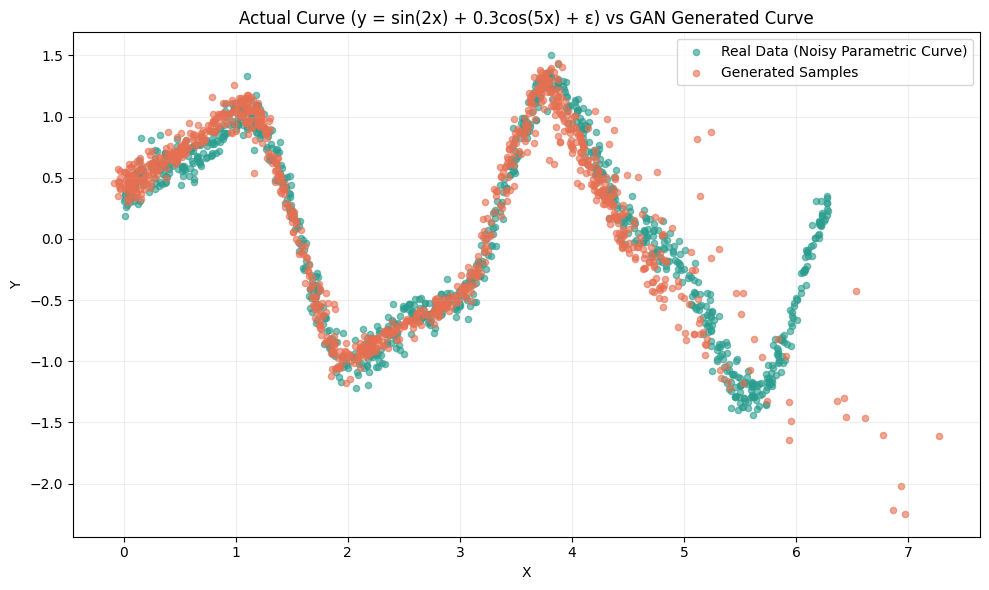

In [ ]:
# Plot comparison
plt.figure(figsize=(10, 6))
plt.scatter(actual_data[:, 0], actual_data[:, 1],
           label='Real Data (Noisy Parametric Curve)', alpha=0.6, s=20, color='#2A9D8F')
plt.scatter(generated_samples_v1[:, 0], generated_samples_v1[:, 1],
           label='Generated Samples', alpha=0.6, s=20, color='#E76F51')

plt.title('Actual Curve (y = sin(2x) + 0.3cos(5x) + ε) vs GAN Generated Curve')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.2)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# **Modified GAN architecture**

In [ ]:
class Discriminator_V2(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


class Generator_V2(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(16, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 2)#,
            # nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
# Assign the modified discriminator and generator object for use
discriminator_v2 = Discriminator_V2()
generator_v2 = Generator_V2()

print("Training modified GAN architecture")
discrimininator_v2_loss, generator_v2_loss = train_gan(discriminator_v2, generator_v2, train_loader, discriminator_lr=0.0001, generator_lr=0.0003, num_epochs = 2000)

Training modified GAN architecture
Epoch 0: Discriminator Loss.: 0.6064 <<--->> Generator Loss.: 0.6633
Epoch 100: Discriminator Loss.: 0.6804 <<--->> Generator Loss.: 0.7111
Epoch 200: Discriminator Loss.: 0.6739 <<--->> Generator Loss.: 0.7270
Epoch 300: Discriminator Loss.: 0.6785 <<--->> Generator Loss.: 0.7205
Epoch 400: Discriminator Loss.: 0.6819 <<--->> Generator Loss.: 0.7102
Epoch 500: Discriminator Loss.: 0.6816 <<--->> Generator Loss.: 0.7163
Epoch 600: Discriminator Loss.: 0.6838 <<--->> Generator Loss.: 0.7166
Epoch 700: Discriminator Loss.: 0.6871 <<--->> Generator Loss.: 0.7127
Epoch 800: Discriminator Loss.: 0.6916 <<--->> Generator Loss.: 0.7130
Epoch 900: Discriminator Loss.: 0.6902 <<--->> Generator Loss.: 0.7073
Epoch 1000: Discriminator Loss.: 0.6906 <<--->> Generator Loss.: 0.6950
Epoch 1100: Discriminator Loss.: 0.6943 <<--->> Generator Loss.: 0.7033
Epoch 1200: Discriminator Loss.: 0.6933 <<--->> Generator Loss.: 0.6953
Epoch 1300: Discriminator Loss.: 0.6924 <

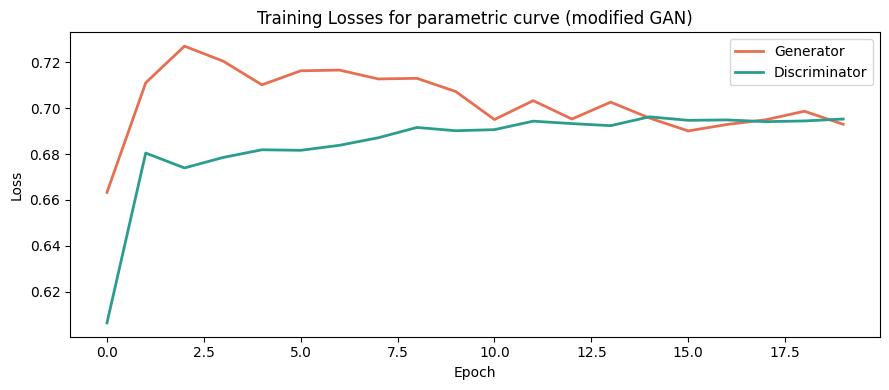

In [ ]:
# Plot losses on GAN data (parametric curve)
plot_losses(generator_v2_loss, discrimininator_v2_loss, "Training Losses for parametric curve (modified GAN)")

In [ ]:
# Generate 1000 samples
generated_samples_v2 = generate_gan_samples(generator_v2)
actual_data = train_data.numpy()

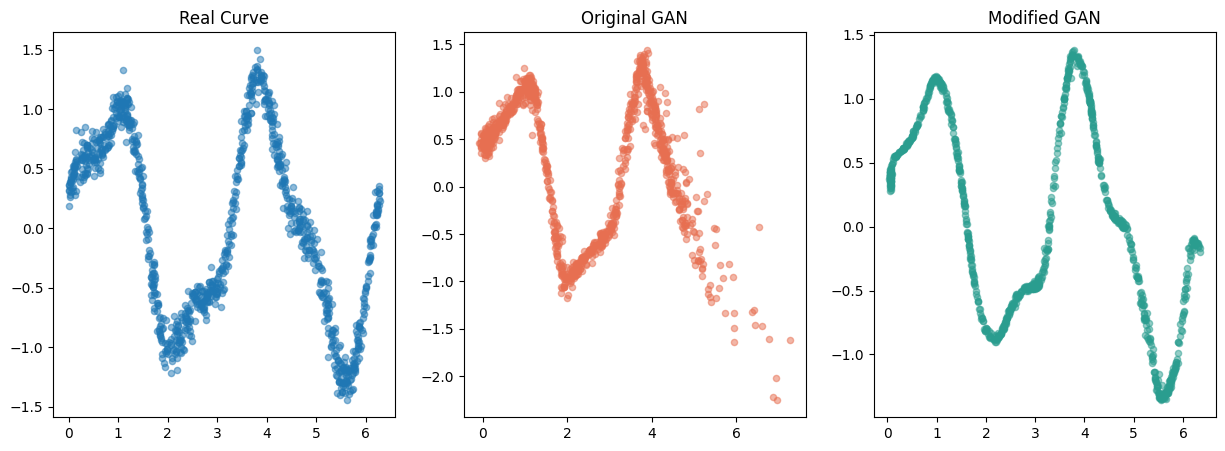

In [ ]:
plt.figure(figsize=(15, 5))

# Actual curve
plt.subplot(1, 3, 1)
plt.scatter(actual_data[:, 0], actual_data[:, 1], alpha=0.5, s=20)
plt.title("Real Curve")

# Original GAN architecture
plt.subplot(1, 3, 2)
plt.scatter(generated_samples_v1[:, 0], generated_samples_v1[:, 1], alpha=0.5, s=20, color='#E76F51')
plt.title("Original GAN")

# modified GAN architecture
plt.subplot(1, 3, 3)
plt.scatter(generated_samples_v2[:, 0], generated_samples_v2[:, 1], alpha=0.5, s=20, color='#2A9D8F')
plt.title("Modified GAN")

plt.show()

In [ ]:
# Evaluation metrics for Noisy curve based
# on original GAN before modification
evaluate_gan(actual_data, generated_samples_v1, label="Noisy Curve - V1 (Original)")


  Evaluation: Noisy Curve - V1 (Original)
Metric                     Real    Generated Difference
-------------------------------------------------------
  Mean (axis X)   3.0962       2.5321   0.5640
  Std  (axis X)   1.8668       1.6299   0.2369
  Mean (axis Y)   0.0128       0.2291   0.2163
  Std  (axis Y)   0.7535       0.7243   0.0292



In [ ]:
# Evaluation metrics for Noisy curve after GAN modification
evaluate_gan(actual_data, generated_samples_v2, label="V2 - Modified Architecture")


  Evaluation: V2 - Modified Architecture
Metric                     Real    Generated Difference
-------------------------------------------------------
  Mean (axis X)   3.0962       3.0801   0.0161
  Std  (axis X)   1.8668       1.8880   0.0213
  Mean (axis Y)   0.0128       0.0402   0.0274
  Std  (axis Y)   0.7535       0.7678   0.0144

